In [1]:
import os
import pickle
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf



In [2]:
# downloading and saving S&P 500 data from 2005 to 2024
import requests
from io import StringIO

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}

response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', headers=headers)
table = pd.read_html(StringIO(response.text))
tickers = table[0]['Symbol'].tolist()
prices = yf.download(tickers, start='2005-01-01', end='2024-01-01')['Close']
prices.to_csv('data/sp500_prices.csv')

#downloading and saving VIX data from 2005 and 2024
vix = yf.download('^VIX', start='2005-01-01', end='2024-01-01')['Close']
vix.to_csv('data/vix.csv')

[******                12%                       ]  58 of 503 completed$BRK.B: possibly delisted; no timezone found
[******                13%                       ]  66 of 503 completed$Q: possibly delisted; no price data found  (1d 2005-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1704085200")
[********              17%                       ]  83 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2005-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1704085200")
[********************  42%                       ]  211 of 503 completed$SOLV: possibly delisted; no price data found  (1d 2005-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1704085200")
[********************* 43%                       ]  215 of 503 completed$GEV: possibly delisted; no price data found  (1d 2005-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist f

In [3]:
# C 3: load from CSV and clean
prices = pd.read_csv('data/sp500_prices.csv', index_col=0, parse_dates=True)
vixData = pd.read_csv('data/vix.csv', index_col=0, parse_dates=True).squeeze()

# drop stocks with >20% missing
prices = prices.dropna(thresh=int(0.9 * len(prices)), axis=1)
prices = prices.ffill().bfill()

print(f"Stocks: {prices.shape[1]}  |  Days: {prices.shape[0]}")
print(f"Range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"VIX rows: {len(vixData)}")


Stocks: 401  |  Days: 4781
Range: 2005-01-03 to 2023-12-29
VIX rows: 4781


In [4]:
# C 4: log returns
logReturns = np.log(prices/ prices.shift(1)).dropna()
print(f"Returns: {logReturns.shape}  (T x N)")


Returns: (4780, 401)  (T x N)


In [5]:
# C 5: regime windows
regimes = {
    'Normal (2012-2014)': ('2012-01-01', '2014-12-31'),
    'GFC (2008-2009)':    ('2008-09-01', '2009-03-31'), #GFC = global financial crisis
    'COVID (2020)':       ('2020-02-01', '2020-05-31'),
}

regimeReturns = {}
for name, (start, end) in regimes.items():
    regimeReturns[name] = logReturns.loc[start:end]

for name, ret in regimeReturns.items():
    T, N = ret.shape
    print(f"{name:<25}  T={T:>4}  N={N:>4}  q={T/N:.3f}")


Normal (2012-2014)         T= 754  N= 401  q=1.880
GFC (2008-2009)            T= 146  N= 401  q=0.364
COVID (2020)               T=  82  N= 401  q=0.204


In [6]:
# C 6: correlation matrix
def computeCorrelationMatrix(returns):
    if isinstance(returns, pd.DataFrame):
        returns = returns.values #converting the returns data into a numpy array (just incase it was any other type)
    return np.corrcoef(returns.T) #using numpy for creating correlation matrix 


In [7]:
# C 7: eigendecomposition
def eigendecompose(C):
    vals, vecs = np.linalg.eigh(C) #using eigh since the input matrix is symmetric (or hermitian) so to speed it up
    idx = np.argsort(vals)[::-1]
    return vals[idx], vecs[:, idx]
# sorting the eigenvalues from biggest to smallest and their related eigenvectors 

In [8]:
# C 8: MP law application (marchenko- pastur) by creating a fitting curve 
def computeLambdaPlus(q, sigma2):
    return sigma2 * (1 + 1 / np.sqrt(q)) ** 2

def computeLambdaMinus(q, sigma2):
    return sigma2 * (1 - 1 / np.sqrt(q)) ** 2

def mpDistribution(lambdaVals, q, sigma2):
    lp = computeLambdaPlus(q, sigma2)
    lm = computeLambdaMinus(q, sigma2)
    density = np.zeros_like(lambdaVals, dtype=float)
    mask = (lambdaVals >= lm) & (lambdaVals <= lp) & (lambdaVals > 0) #0 out the out of bounds values to fit the curve
    l = lambdaVals[mask]
    density[mask] = (q / (2 * np.pi * sigma2)) * np.sqrt((lp - l) * (l - lm)) / l #calculating density function
    return density


In [9]:
# C 9: fit MP — find best sigma^2
def fitMp(eigenvalues, q):
    bulk = eigenvalues[eigenvalues < 3.0 * eigenvalues.mean()] #ASSUMING that most of the eigenvalues above 3 times the mean are signal and not noise
    lambdaGrid = np.linspace(max(bulk.min() * 0.8, 1e-4), bulk.max() * 1.2, 500)

    def objective(params):
        s2 = float(params[0])
        if s2 <= 1e-6:
            return 1e10
        theory = mpDistribution(lambdaGrid, q, s2)
        theory = theory + 1e-12
        theory = theory / theory.sum()
        kde = stats.gaussian_kde(bulk)(lambdaGrid)
        kde = kde / kde.sum()
        mask = (theory > 1e-10) & (kde > 1e-10)
        return float(np.sum(kde[mask] * np.log(kde[mask] / theory[mask])))

    res = minimize(objective, x0=[1.0], method='Nelder-Mead',
                   options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 10000})
    sigma2 = float(res.x[0])
    lambdaPlus = computeLambdaPlus(q, sigma2)
    return sigma2, lambdaPlus


In [10]:
# C 10: run RMT analysis on all three regimes
regimeAnalysis = {}

for name, ret in regimeReturns.items():
    T, N = ret.shape
    q = T / N
    C = computeCorrelationMatrix(ret)
    vals, vecs = eigendecompose(C)
    sigma2, lambdaPlus = fitMp(vals, q)
    nSignal = int((vals > lambdaPlus).sum())

    regimeAnalysis[name] = {
        'T': T, 'N': N, 'q': q,
        'C': C, 'eigenvalues': vals, 'eigenvectors': vecs,
        'sigma2': sigma2, 'lambdaPlus': lambdaPlus, 'nSignal': nSignal,
    }
    print(f"{name:<25}  q={q:.3f}  sigma2={sigma2:.4f} " 
          f"lambda+={lambdaPlus:.4f}  nSignal={nSignal}")


Normal (2012-2014)         q=1.880  sigma2=0.0877 lambda+=0.2623  nSignal=244
GFC (2008-2009)            q=0.364  sigma2=1.2222 lambda+=8.6300  nSignal=2
COVID (2020)               q=0.204  sigma2=0.1992 lambda+=2.0547  nSignal=15


In [11]:
# C 11: denoise function + run on all regimes
def denoiseMatrix(eigenvalues, eigenvectors, lambdaPlus):
    lambdas = eigenvalues.copy()
    noiseMask = lambdas <= lambdaPlus
    if noiseMask.sum() > 0:
        lambdas[noiseMask] = lambdas[noiseMask].mean()

    cDenoised = eigenvectors @ np.diag(lambdas) @ eigenvectors.T #using the diagnolizable property that hermitian matrices are diagnolizable

    # rescale diagonal back to 1
    d = np.sqrt(np.diag(cDenoised))
    d[d < 1e-10] = 1.0
    cDenoised = cDenoised / np.outer(d, d) #setting diagonals back to 1
    np.fill_diagonal(cDenoised, 1.0)
    return cDenoised

for name, data in regimeAnalysis.items():
    cDn = denoiseMatrix(data['eigenvalues'], data['eigenvectors'], data['lambdaPlus'])
    regimeAnalysis[name]['cDenoised'] = cDn
    offDiagMean = (cDn.sum() - cDn.shape[0]) / (cDn.shape[0] * (cDn.shape[0] - 1))
    print(f"{name:<25}  off-diag mean corr = {offDiagMean:.4f}")


Normal (2012-2014)         off-diag mean corr = 0.3121
GFC (2008-2009)            off-diag mean corr = 0.5643
COVID (2020)               off-diag mean corr = 0.6265


In [12]:
# C 12: rolling lambda_max vs VIX (60-day window)
# IMPORTANT: need T > N for a valid correlation matrix, so with a 60-day T we need a smaller value of N say 50 or smaller for convienience
rollWindow = 60
rollStocks = logReturns.columns[:50]
cacheFile = 'data/rolling_analysis.pkl'

if os.path.exists(cacheFile):
    rollingDf = pd.read_pickle(cacheFile)
    print(f"Loaded from cache: {len(rollingDf)} windows")
else:
    retArr = logReturns[rollStocks].values
    dates = logReturns.index
    nRoll = retArr.shape[1]
    print(f"Rolling: T={rollWindow}, N={nRoll}, q={rollWindow/nRoll:.2f}")

    rollDates, rollLmax, rollNsignal = [], [], []

    for i in range(rollWindow, len(retArr)):
        window = retArr[i - rollWindow : i]

        # skip windows with any NaN (can happen at edge)
        if np.isnan(window).any():
            continue

        C = np.corrcoef(window.T)

        # safety: if corrcoef produced NaN, skip
        if np.isnan(C).any():
            continue

        vals = np.linalg.eigvalsh(C)[::-1]
        q = rollWindow / nRoll

        if i % 20 == 0:
            sigma2, _ = fitMp(vals, q)

        lp = computeLambdaPlus(q, sigma2)

        rollDates.append(dates[i])
        rollLmax.append(float(vals[0]))
        rollNsignal.append(int((vals > lp).sum()))

        if i % 1000 == 0:
            print(f"  {dates[i].date()}  lambdaMax={vals[0]:.3f}")

    rollingDf = pd.DataFrame(
        {'lambdaMax': rollLmax, 'nSignal': rollNsignal},
        index=rollDates,
    )
    rollingDf.to_pickle(cacheFile)
    print(f"Done — {len(rollingDf)} windows cached")

vixAligned = vixData.reindex(rollingDf.index, method='nearest')
rollingDf['vix'] = vixAligned.values
corrLmaxVix = rollingDf['lambdaMax'].corr(rollingDf['vix'])
print(f"Pearson(lambdaMax, VIX) = {corrLmaxVix:.3f}")


Loaded from cache: 3948 windows
Pearson(lambdaMax, VIX) = 0.622


In [13]:
# C 13: portfolio construction by 4 methods
portfolioStocks = logReturns.columns[:100]
trainEnd = '2014-12-31'
testStart = '2015-01-01'

trainRet = logReturns.loc[:trainEnd, portfolioStocks]
testRet = logReturns.loc[testStart:, portfolioStocks]
tTrain, nPort = trainRet.shape
qPort = tTrain / nPort
stdVec = trainRet.std().values

def minVarianceWeights(covMatrix):
    N = covMatrix.shape[0]
    ones = np.ones(N)
    covReg = covMatrix + 1e-8 * np.eye(N)
    try:
        covInv = np.linalg.inv(covReg)
        w = covInv @ ones
        w = w / (ones @ w)
    except np.linalg.LinAlgError:
        w = ones / N
    w = np.maximum(w, 0)
    w = w / w.sum() if w.sum() > 0 else ones / N
    return w

#Method 1: sample covariance ie using the default noisy matrix
covSample = np.cov(trainRet.T) * 252
wSample = minVarianceWeights(covSample)

#Method 2: Ledoit-Wolf shrinkage (actual competition against RMT)
lw = LedoitWolf().fit(trainRet.values)
covLw = lw.covariance_ * 252
wLw = minVarianceWeights(covLw)

#Method 3: constant correlation (replacing all values by a mean correlation)
corrRaw = np.corrcoef(trainRet.T)
meanRho = (corrRaw.sum() - nPort) / (nPort * (nPort - 1))
cCc = np.full((nPort, nPort), meanRho)
np.fill_diagonal(cCc, 1.0)
covCc = np.outer(stdVec, stdVec) * cCc * 252
wCc = minVarianceWeights(covCc)

#Method 4: RMT denoised ie our method
cTrain = computeCorrelationMatrix(trainRet)
evalsT, evecsT = eigendecompose(cTrain)
_, lpTrain = fitMp(evalsT, qPort)
cRmt = denoiseMatrix(evalsT, evecsT, lpTrain)
covRmt = np.outer(stdVec, stdVec) * cRmt * 252
wRmt = minVarianceWeights(covRmt)

allWeights = {
    'Sample': wSample,
    'Ledoit-Wolf': wLw,
    'Const Corr': wCc,
    'RMT Denoised': wRmt,
}

for mName, w in allWeights.items():
    effN = 1.0 / np.sum(w ** 2)
    print(f"{mName:<15}  maxW={w.max():.3f}  effN={effN:.1f}")


Sample           maxW=0.076  effN=27.4
Ledoit-Wolf      maxW=0.073  effN=28.1
Const Corr       maxW=0.066  effN=25.6
RMT Denoised     maxW=0.067  effN=26.3


In [14]:
# C 14: out-of-sample validation
def portfolioMetrics(returnsSeries):
    annRet = returnsSeries.mean() * 252
    annVol = returnsSeries.std() * np.sqrt(252)
    sharpe = annRet / annVol if annVol > 1e-10 else 0.0
    cum = (1 + returnsSeries).cumprod()
    maxDd = (cum / cum.cummax() - 1).min()
    return {'annReturn': annRet, 'annVol': annVol, 'sharpe': sharpe, 'maxDd': maxDd}

testArr = testRet.values
perf = {}

for mName, w in allWeights.items():
    portRet = pd.Series(testArr @ w, index=testRet.index)
    m = portfolioMetrics(portRet)
    m['returns'] = portRet
    m['cumulative'] = (1 + portRet).cumprod()
    perf[mName] = m

print(f"{'Method':<15} {'Sharpe':>8} {'AnnVol':>8} {'AnnRet':>9} {'MaxDD':>8}")
print('-' * 54)
for mName, m in perf.items():
    print(f"{mName:<15}  {m['sharpe']:7.3f}  {m['annVol']:7.2%}  "
          f"{m['annReturn']:8.2%}  {m['maxDd']:7.2%}")


Method            Sharpe   AnnVol    AnnRet    MaxDD
------------------------------------------------------
Sample             0.715   15.77%    11.28%  -33.26%
Ledoit-Wolf        0.715   15.75%    11.26%  -33.17%
Const Corr         0.608   15.16%     9.22%  -29.88%
RMT Denoised       0.695   15.74%    10.93%  -33.06%


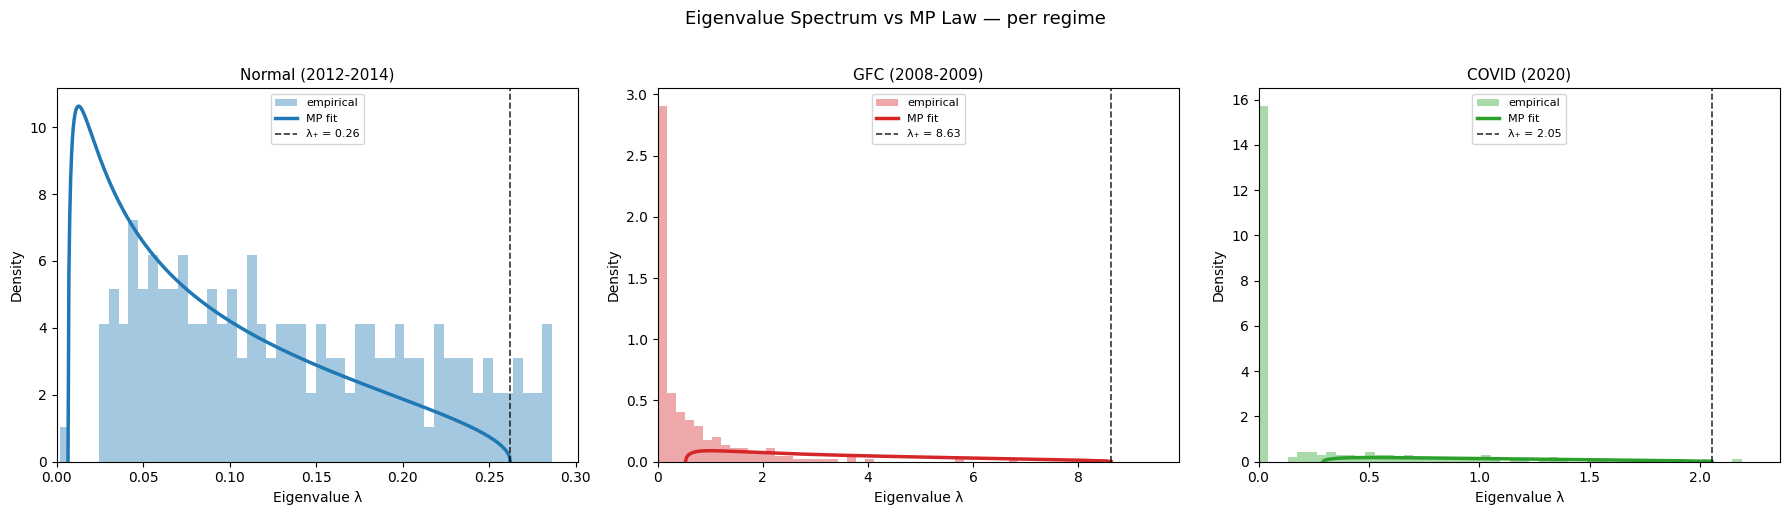

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, data) in zip(axes, regimeAnalysis.items()):
    vals = data['eigenvalues']
    q    = data['q']
    s2   = data['sigma2']
    lp   = data['lambdaPlus']
    lm   = computeLambdaMinus(q, s2)

    # only plot the bulk region — clip at lp * 1.1
    bulk = vals[(vals > 0) & (vals <= lp * 1.1)]
    ax.hist(bulk, bins=50, density=True, alpha=0.4,
            color=colors[name], label='empirical')

    # MP curve on a tight grid matching the bulk
    grid = np.linspace(max(lm, 1e-4), lp, 500)
    mp   = mpDistribution(grid, q, s2)
    ax.plot(grid, mp, color=colors[name], lw=2.5, label='MP fit')

    # λ₊ line
    ax.axvline(lp, color='black', ls='--', lw=1.2, alpha=0.8,
               label=f'λ₊ = {lp:.2f}')

    ax.set_xlim(0, lp * 1.15)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Eigenvalue λ')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Eigenvalue Spectrum vs MP Law — per regime', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/plot1_spectrum_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Jai\AppData\Local\Temp\ipykernel_33984\867685027.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\Jai\AppData\Local\Temp\ipykernel_33984\867685027.py:17: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


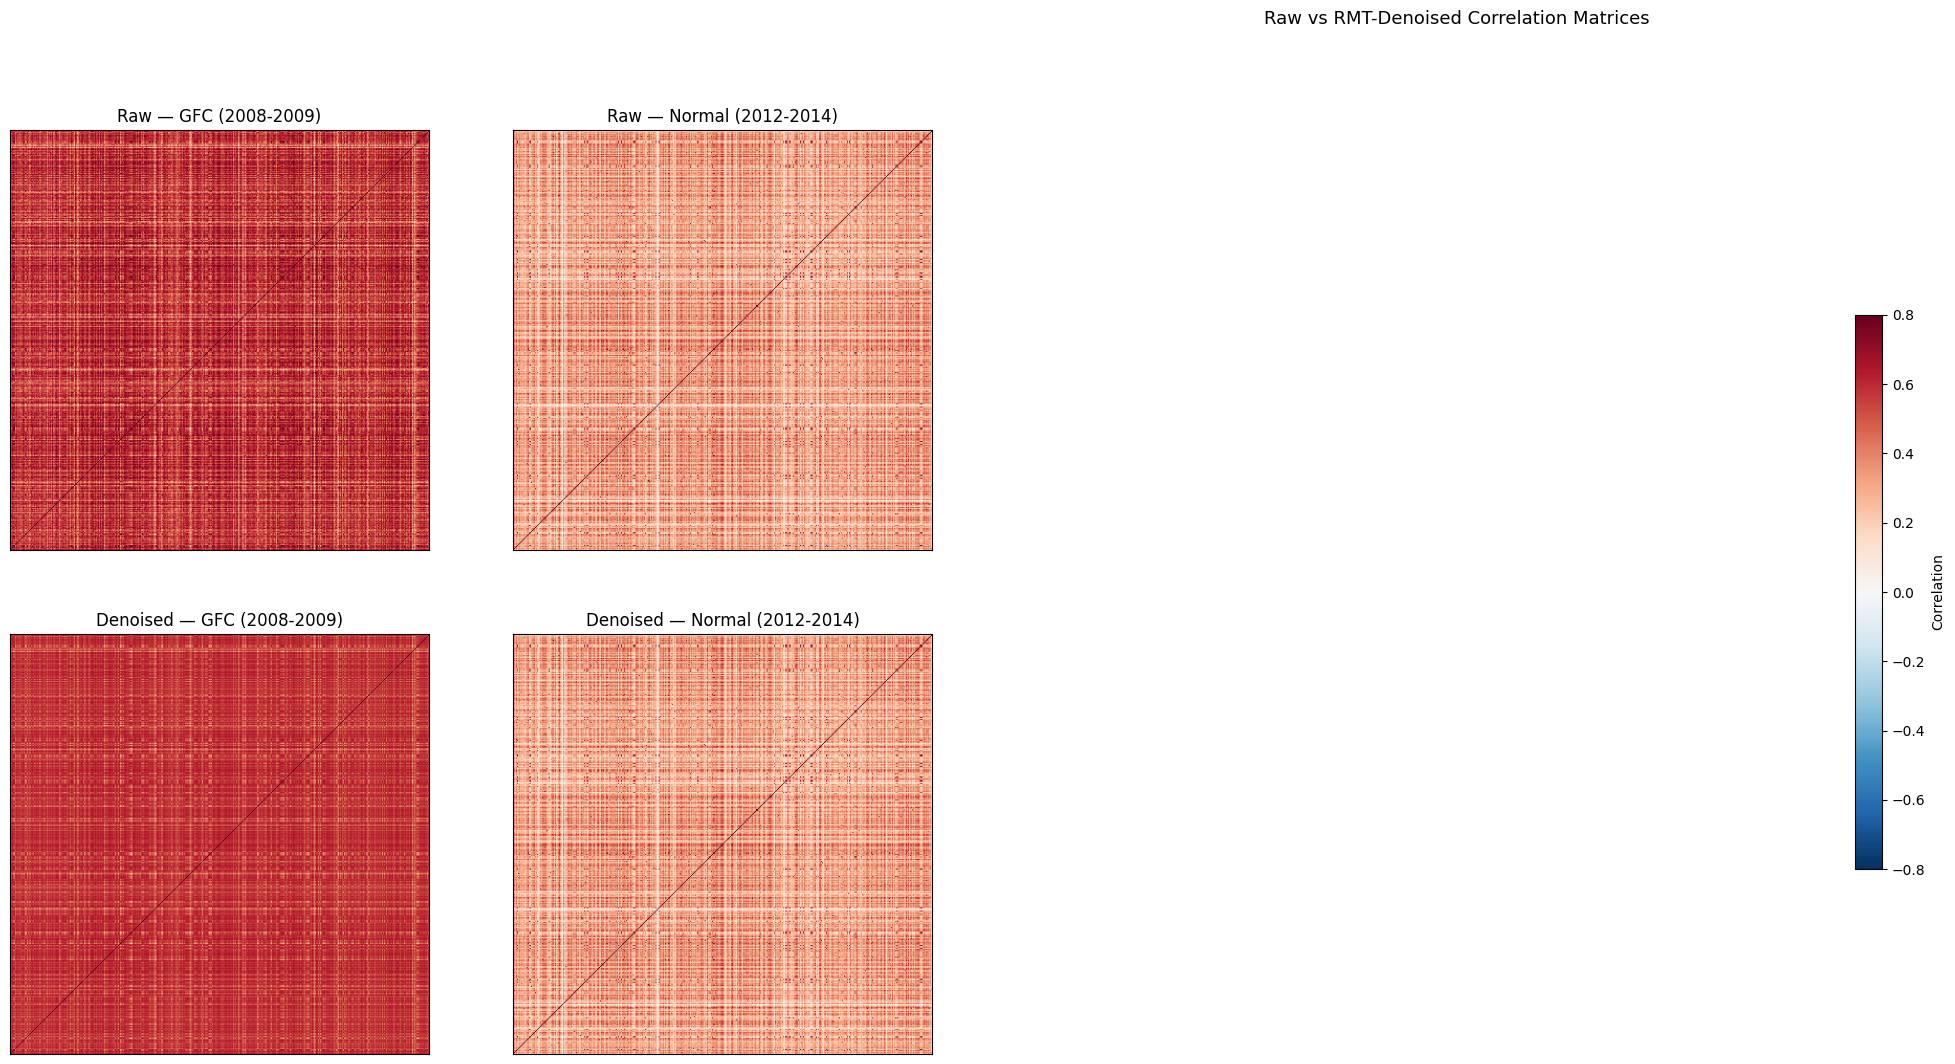

In [16]:
# C 16: Plot 2 — Raw vs denoised correlation heatmaps
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

pairNames = ['Normal (2012-2014)', 'GFC (2008-2009)']

for col, rName in enumerate(pairNames):
    axes[0, col].imshow(regimeAnalysis[rName]['C'], cmap='RdBu_r', vmin=-0.8, vmax=0.8, aspect='auto')
    axes[0, col].set_title(f'Raw — {rName}')
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

    im = axes[1, col].imshow(regimeAnalysis[rName]['cDenoised'], cmap='RdBu_r', vmin=-0.8, vmax=0.8, aspect='auto')
    axes[1, col].set_title(f'Denoised — {rName}')
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

plt.colorbar(im, ax=axes, shrink=0.6, label='Correlation',  pad = 1.7)
plt.suptitle('Raw vs RMT-Denoised Correlation Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('plots/plot2_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


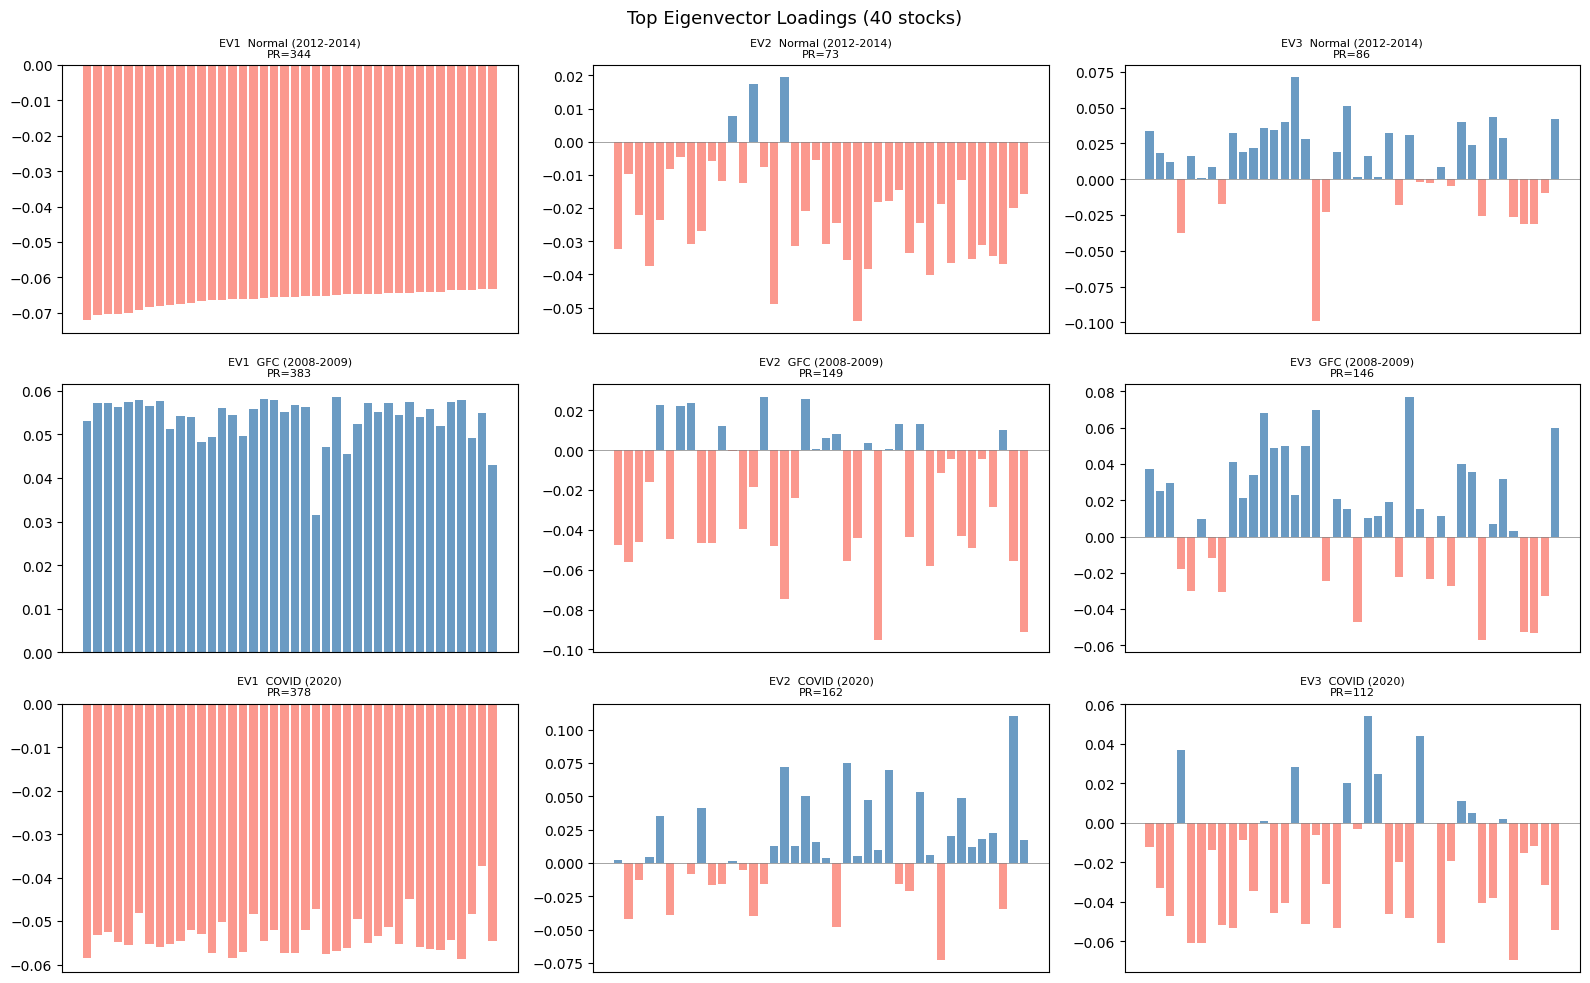

In [17]:
# C 17: Plot 3 — Top eigenvector loadings
nEig = 3
nStocks = 40

refVals = regimeAnalysis['Normal (2012-2014)']['eigenvectors'][:, 0]
topIdx = np.argsort(np.abs(refVals))[::-1][:nStocks]

fig, axes = plt.subplots(len(regimeAnalysis), nEig, figsize=(16, 10))

for rowIdx, (rName, data) in enumerate(regimeAnalysis.items()):
    evecs = data['eigenvectors']
    for colIdx in range(nEig):
        ax = axes[rowIdx, colIdx]
        validIdx = topIdx[topIdx < evecs.shape[0]]
        loadings = evecs[validIdx, colIdx]
        barColors = ['steelblue' if v >= 0 else 'salmon' for v in loadings]
        ax.bar(range(len(loadings)), loadings, color=barColors, alpha=0.8)
        ax.axhline(0, color='gray', lw=0.5)
        pr = 1.0 / np.sum(evecs[:, colIdx] ** 4)
        ax.set_title(f"EV{colIdx+1}  {rName}\nPR={pr:.0f}", fontsize=8)
        ax.set_xticks([])

plt.suptitle('Top Eigenvector Loadings (40 stocks)', fontsize=13)
plt.tight_layout()
plt.savefig('plots/plot3_eigenvectors.png', dpi=150, bbox_inches='tight')
plt.show()


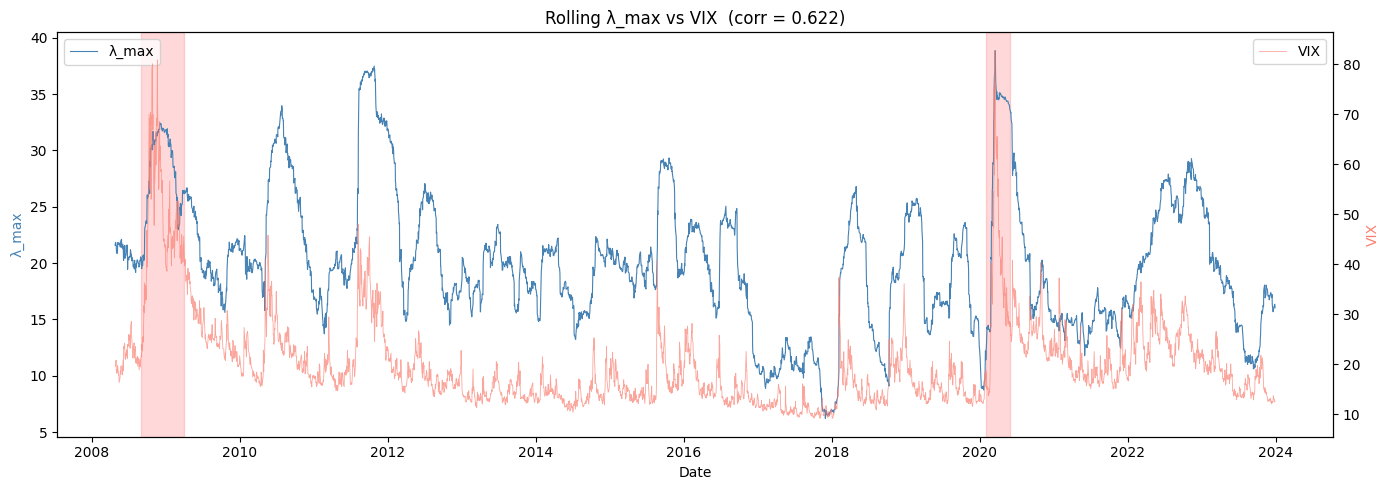

In [18]:
# C 18: Plot 4 — Rolling lambda_max vs VIX
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(rollingDf.index, rollingDf['lambdaMax'], color='steelblue', lw=0.8, label='λ_max')
ax1.set_ylabel('λ_max', color='steelblue')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(rollingDf.index, rollingDf['vix'], color='salmon', lw=0.6, alpha=0.7, label='VIX')
ax2.set_ylabel('VIX', color='salmon')

# crisis shading
for start, end, lbl in [('2008-09-01','2009-03-31','GFC'),
                          ('2020-02-01','2020-05-31','COVID')]:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color='red')

ax1.set_title(f'Rolling λ_max vs VIX  (corr = {corrLmaxVix:.3f})')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('plots/plot4_rolling_lambda.png', dpi=150, bbox_inches='tight')
plt.show()


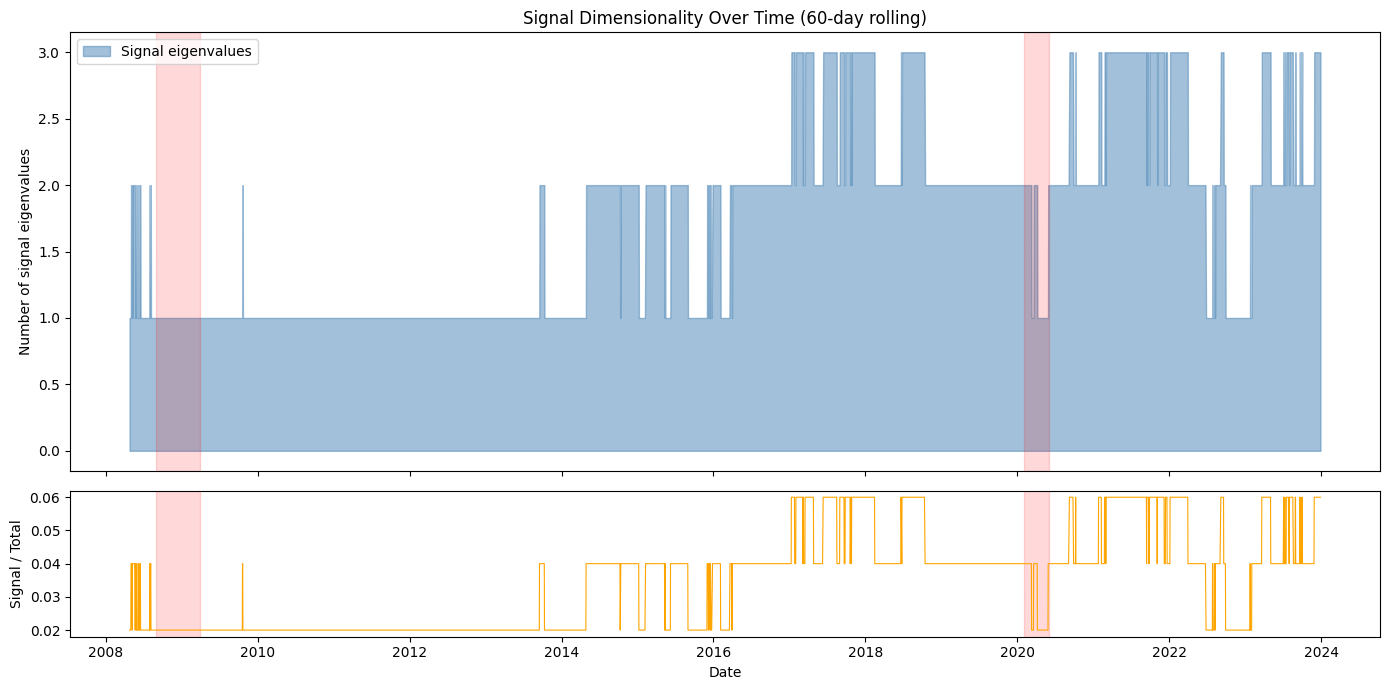

In [19]:
# C 19: Plot 5 — Signal dimensionality over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.fill_between(rollingDf.index, rollingDf['nSignal'], alpha=0.5, color='steelblue', label='Signal eigenvalues')
ax1.set_ylabel('Number of signal eigenvalues')
ax1.set_title('Signal Dimensionality Over Time (60-day rolling)')
ax1.legend()

# ratio of signal to total
nTotal = len(rollStocks)
ax2.plot(rollingDf.index, rollingDf['nSignal'] / nTotal, color='orange', lw=0.8)
ax2.set_ylabel('Signal / Total')
ax2.set_xlabel('Date')

for start, end in [('2008-09-01','2009-03-31'), ('2020-02-01','2020-05-31')]:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color='red')
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color='red')

plt.tight_layout()
plt.savefig('plots/plot5_signal_count.png', dpi=150, bbox_inches='tight')
plt.show()


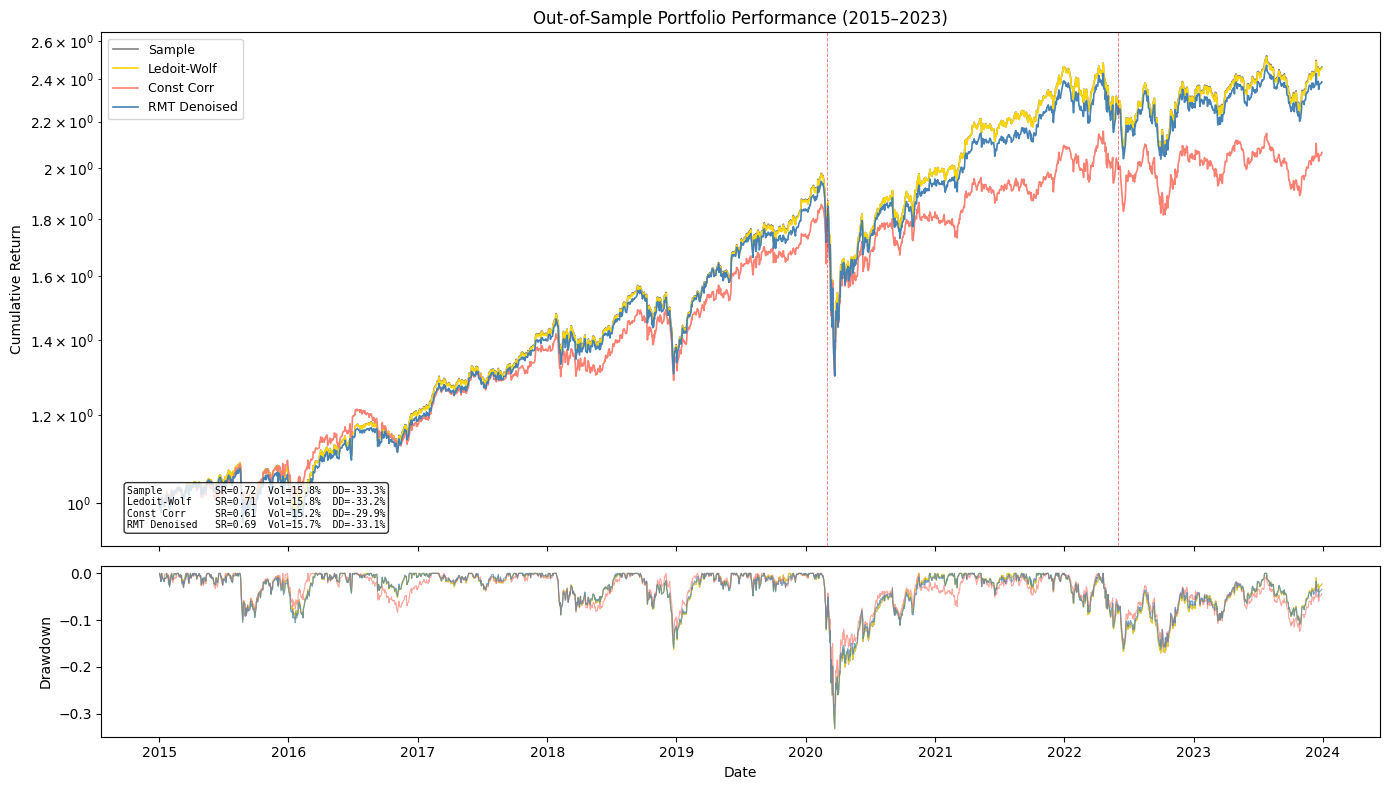

In [20]:
# C 20: Plot 6 — Portfolio cumulative returns + drawdown
methodColors = {'Sample': 'gray', 'Ledoit-Wolf': 'gold', 'Const Corr': 'salmon', 'RMT Denoised': 'steelblue'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

for mName, m in perf.items():
    ax1.plot(m['cumulative'].index, m['cumulative'].values, label=mName, color=methodColors[mName], lw=1.2)
    dd = m['cumulative'] / m['cumulative'].cummax() - 1
    ax2.plot(dd.index, dd.values, color=methodColors[mName], lw=0.8, alpha=0.7)

ax1.set_ylabel('Cumulative Return')
ax1.set_title('Out-of-Sample Portfolio Performance (2015–2023)')
ax1.legend(fontsize=9)
ax1.set_yscale('log')

ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')

# event lines
for date, lbl in [('2020-03-01', 'COVID'), ('2022-06-01', 'Rate hikes')]:
    ax1.axvline(pd.Timestamp(date), color='red', ls='--', lw=0.7, alpha=0.5)

# performance table
tableStr = '\n'.join([f"{m:<14} SR={perf[m]['sharpe']:.2f}  Vol={perf[m]['annVol']:.1%}  DD={perf[m]['maxDd']:.1%}"
                      for m in perf])
ax1.text(0.02, 0.03, tableStr, transform=ax1.transAxes, fontsize=7, family='monospace',
         va='bottom', bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/plot6_portfolios.png', dpi=150, bbox_inches='tight')
plt.show()


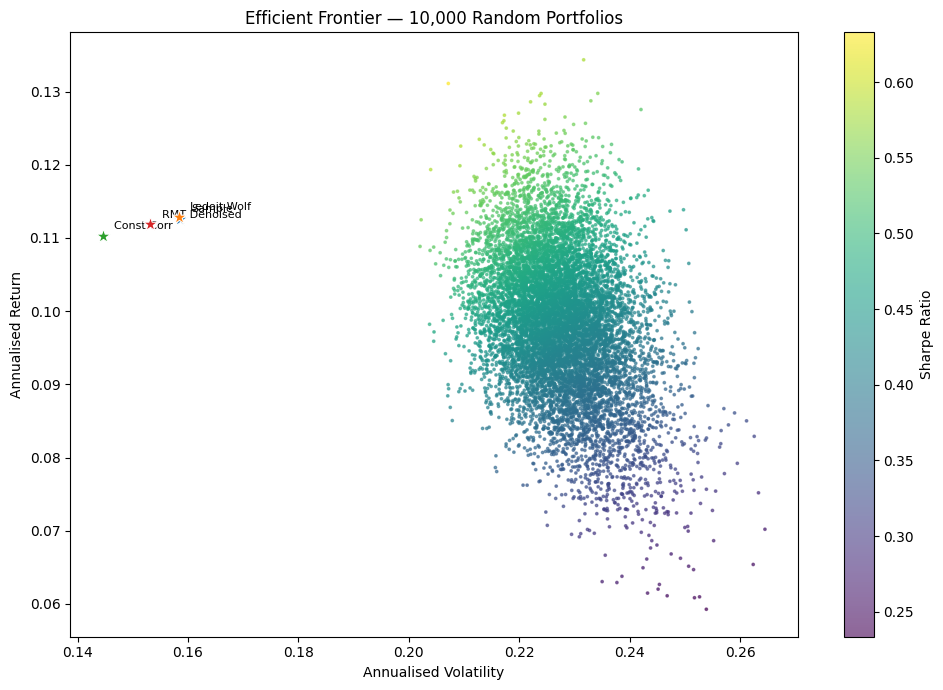

In [21]:
# C 21: Plot 7 — Efficient frontier (just for eye grab)
np.random.seed(42)
nPortfolios = 10000
nAssets = covRmt.shape[0]

randReturns = []
randVols = []
randSharpes = []

meanReturns = trainRet.mean().values * 252

for _ in range(nPortfolios):
    w = np.random.dirichlet(np.ones(nAssets))
    pRet = w @ meanReturns
    pVol = np.sqrt(w @ covRmt @ w)
    sr = pRet / pVol if pVol > 1e-10 else 0
    randReturns.append(pRet)
    randVols.append(pVol)
    randSharpes.append(sr)

randReturns = np.array(randReturns)
randVols = np.array(randVols)
randSharpes = np.array(randSharpes)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(randVols, randReturns, c=randSharpes, cmap='viridis', s=3, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# mark the 4 methods
for mName, w in allWeights.items():
    pRet = w @ meanReturns
    pVol = np.sqrt(w @ covRmt @ w)
    ax.scatter(pVol, pRet, s=120, marker='*', zorder=10, edgecolors='white', linewidths=0.8)
    ax.annotate(mName, (pVol, pRet), textcoords='offset points', xytext=(8, 5), fontsize=8)

ax.set_xlabel('Annualised Volatility')
ax.set_ylabel('Annualised Return')
ax.set_title('Efficient Frontier — 10,000 Random Portfolios')
plt.tight_layout()
plt.savefig('plots/plot7_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
